In [1]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from gnews import GNews
from datetime import datetime

import os
import time

from transformers import AutoTokenizer,AutoModelForSequenceClassification,pipeline,DistilBertTokenizer

In [1]:
'''gn = GNews(language='en', country='US', max_results=5)

# Top news
top = gn.get_top_news()

# Search by keyword
results = gn.get_news('artificial intelligence')

# By topic
tech_news = gn.get_news_by_topic('TECHNOLOGY')

# By location
india_news = gn.get_news_by_location('India')

# Full article
article = gn.get_full_article(results[0]['url'])
print(article.text))'''

"gn = GNews(language='en', country='US', max_results=5)\n\n# Top news\ntop = gn.get_top_news()\n\n# Search by keyword\nresults = gn.get_news('artificial intelligence')\n\n# By topic\ntech_news = gn.get_news_by_topic('TECHNOLOGY')\n\n# By location\nindia_news = gn.get_news_by_location('India')\n\n# Full article\narticle = gn.get_full_article(results[0]['url'])\nprint(article.text))"

In [8]:
def acquire_news_keyword(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    _=pd.DataFrame(gn.get_news(topic))
    _['time_of_collection']=datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    _['time_of_collection'] = pd.to_datetime(_['time_of_collection'],format='mixed',dayfirst=True)
    _.index=pd.to_datetime(_['published date'])
    _['date'] = _['time_of_collection'].dt.normalize()
    _['ticker']=topic
    return _
    del _

def acquire_news_top(results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_top_news()

def acquire_news_topic(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

#drops all rows that present in old_news
def filter_new_news(new_news:pd.DataFrame,old_news:pd.DataFrame):
    x=0
    for index,title in enumerate(new_news.iloc[:,0]):
        if title in old_news.iloc[:,0].values:
            new_news.drop(index=index,axis=1,inplace=True)
            x=x+1
        else:
            pass
    print('Total news dropped:',x)

def record_news(new_news:pd.DataFrame,ticker:str,header:bool = False,mode:str = 'a'):
    new_news.to_csv(rf"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews\{ticker}.csv",header=header,index=False,mode=mode)

def acquire_sentiment(new_news: pd.DataFrame):
    classifier = pipeline('text-classification', model="ProsusAI/finbert")

    texts = new_news.iloc[:, 1].tolist()
    results = classifier(texts, top_k=None)
    print(results)
    time.sleep(10)

    probs = [{d['label']: d['score'] for d in res} for res in results]

    probs_df = pd.DataFrame(probs)

    new_news = pd.concat([new_news.reset_index(drop=True), probs_df], axis=1)
    new_news['label'] = probs_df.idxmax(axis=1)
    new_news['sentiment_score']=new_news['positive'] - new_news['negative']

    return new_news

In [3]:
path=r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"

In [11]:
ndf=pd.DataFrame(acquire_news_keyword(topic='Microsoft',results=100))

In [12]:
ndf.head()

,title,description,published date,url,publisher,time_of_collection,date
published date,,,,,,,
2026-03-25 16:35:00,Microsoft Makes Sweeping Overhaul of HR Organi...,Microsoft Makes Sweeping Overhaul of HR Organi...,"Wed, 25 Mar 2026 16:35:00 GMT",https://news.google.com/rss/articles/CBMisAFBV...,"{'href': 'https://www.businessinsider.com', 't...",2026-03-26 19:35:52,2026-03-26
2026-03-25 21:00:00,Microsoft’s stock is having its worst quarter ...,Microsoft’s stock is having its worst quarter ...,"Wed, 25 Mar 2026 21:00:00 GMT",https://news.google.com/rss/articles/CBMizgNBV...,"{'href': 'https://www.marketwatch.com', 'title...",2026-03-26 19:35:52,2026-03-26
2026-03-26 13:00:00,Vena Completes Acterys Acquisition to Accelera...,Vena Completes Acterys Acquisition to Accelera...,"Thu, 26 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMimgFBV...,"{'href': 'https://ca.finance.yahoo.com', 'titl...",2026-03-26 19:35:52,2026-03-26
2026-03-25 14:36:25,Microsoft backtracks on Copilot Chat access in...,Microsoft backtracks on Copilot Chat access in...,"Wed, 25 Mar 2026 14:36:25 GMT",https://news.google.com/rss/articles/CBMiqwFBV...,"{'href': 'https://www.computerworld.com', 'tit...",2026-03-26 19:35:52,2026-03-26
2026-03-25 23:51:00,Judge Approves Testimony that Microsoft Could ...,Judge Approves Testimony that Microsoft Could ...,"Wed, 25 Mar 2026 23:51:00 GMT",https://news.google.com/rss/articles/CBMiogFBV...,"{'href': 'https://www.theinformation.com', 'ti...",2026-03-26 19:35:52,2026-03-26


In [77]:
record_news(ndf,header=False,ticker='Microsoft')
del ndf

In [30]:
news_df=pd.read_csv(path+'\\Microsoft.csv')
news_df.head()

,title,description,published date,url,publisher,time_of_collection,date
0,Less AI? Microsoft Pledges to Focus on Windows...,Less AI? Microsoft Pledges to Focus on Windows...,"Sun, 22 Mar 2026 21:50:17 GMT",https://news.google.com/rss/articles/CBMiowFBV...,"{'href': 'https://www.pcmag.com', 'title': 'PC...",2026-03-24 22:28:00,2026-03-24
1,Microsoft and Nvidia team up on AI nuclear pus...,Microsoft and Nvidia team up on AI nuclear pus...,"Tue, 24 Mar 2026 16:03:38 GMT",https://news.google.com/rss/articles/CBMif0FVX...,"{'href': 'https://www.axios.com', 'title': 'Ax...",2026-03-24 22:28:00,2026-03-24
2,Microsoft to Rent Texas Data Center Dropped by...,Microsoft to Rent Texas Data Center Dropped by...,"Tue, 24 Mar 2026 15:16:35 GMT",https://news.google.com/rss/articles/CBMisAFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",2026-03-24 22:28:00,2026-03-24
3,RSA Announces Expanded Partnership with Micros...,RSA Announces Expanded Partnership with Micros...,"Tue, 24 Mar 2026 16:00:00 GMT",https://news.google.com/rss/articles/CBMimAFBV...,"{'href': 'https://sg.finance.yahoo.com', 'titl...",2026-03-24 22:28:00,2026-03-24
4,"After billions of funding and multi-year deal,...","After billions of funding and multi-year deal,...","Tue, 24 Mar 2026 06:18:00 GMT",https://news.google.com/rss/articles/CBMigAJBV...,{'href': 'https://timesofindia.indiatimes.com'...,2026-03-24 22:28:00,2026-03-24


In [45]:
news_df=acquire_sentiment(news_df)

[[{'label': 'negative', 'score': 0.9411757588386536}, {'label': 'neutral', 'score': 0.04863310977816582}, {'label': 'positive', 'score': 0.010191163048148155}], [{'label': 'positive', 'score': 0.5493444800376892}, {'label': 'neutral', 'score': 0.4341302216053009}, {'label': 'negative', 'score': 0.01652531512081623}], [{'label': 'neutral', 'score': 0.8373562097549438}, {'label': 'negative', 'score': 0.14120079576969147}, {'label': 'positive', 'score': 0.021442951634526253}], [{'label': 'positive', 'score': 0.9388555884361267}, {'label': 'neutral', 'score': 0.050540484488010406}, {'label': 'negative', 'score': 0.010603848844766617}], [{'label': 'neutral', 'score': 0.7943408489227295}, {'label': 'positive', 'score': 0.19190041720867157}, {'label': 'negative', 'score': 0.013758704997599125}], [{'label': 'neutral', 'score': 0.5368467569351196}, {'label': 'negative', 'score': 0.43364089727401733}, {'label': 'positive', 'score': 0.02951234206557274}], [{'label': 'neutral', 'score': 0.86654025

In [46]:
news_df.head()

,title,description,published date,url,publisher,time_of_collection,date,negative,neutral,positive,label,sentiment_score
0,Less AI? Microsoft Pledges to Focus on Windows...,Less AI? Microsoft Pledges to Focus on Windows...,"Sun, 22 Mar 2026 21:50:17 GMT",https://news.google.com/rss/articles/CBMiowFBV...,"{'href': 'https://www.pcmag.com', 'title': 'PC...",2026-03-24 22:28:00,2026-03-24,0.941176,0.048633,0.010191,negative,-0.930985
1,Microsoft and Nvidia team up on AI nuclear pus...,Microsoft and Nvidia team up on AI nuclear pus...,"Tue, 24 Mar 2026 16:03:38 GMT",https://news.google.com/rss/articles/CBMif0FVX...,"{'href': 'https://www.axios.com', 'title': 'Ax...",2026-03-24 22:28:00,2026-03-24,0.016525,0.434130,0.549344,positive,0.532819
2,Microsoft to Rent Texas Data Center Dropped by...,Microsoft to Rent Texas Data Center Dropped by...,"Tue, 24 Mar 2026 15:16:35 GMT",https://news.google.com/rss/articles/CBMisAFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",2026-03-24 22:28:00,2026-03-24,0.141201,0.837356,0.021443,neutral,-0.119758
3,RSA Announces Expanded Partnership with Micros...,RSA Announces Expanded Partnership with Micros...,"Tue, 24 Mar 2026 16:00:00 GMT",https://news.google.com/rss/articles/CBMimAFBV...,"{'href': 'https://sg.finance.yahoo.com', 'titl...",2026-03-24 22:28:00,2026-03-24,0.010604,0.050540,0.938856,positive,0.928252
4,"After billions of funding and multi-year deal,...","After billions of funding and multi-year deal,...","Tue, 24 Mar 2026 06:18:00 GMT",https://news.google.com/rss/articles/CBMigAJBV...,{'href': 'https://timesofindia.indiatimes.com'...,2026-03-24 22:28:00,2026-03-24,0.013759,0.794341,0.191900,neutral,0.178142


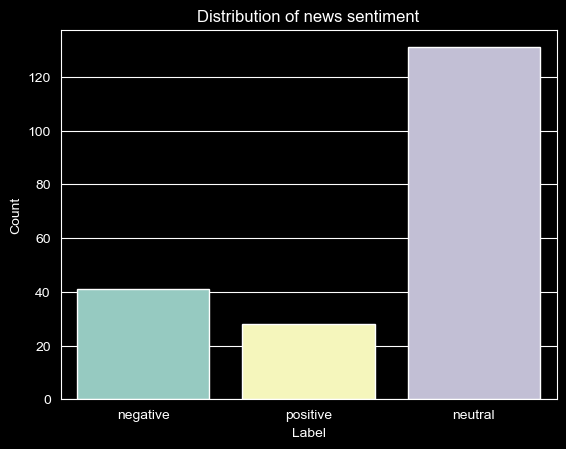

In [22]:
sns.countplot(data=news_df,x="label",hue="label")
plt.title('Distribution of news sentiment')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [28]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=news_df.index,y=news_df['confidence'],mode='markers'))
fig.show()

In [51]:
news_df.groupby('date').agg({
    'confidence': 'mean',   # numeric
})

,confidence
date,
2026-03-24,0.781808
2026-03-26,0.801670


In [67]:
fig=go.Figure()
for time in news_df['date'].value_counts().index:
    fig.add_trace(go.Scatter(x=news_df[news_df['date']==time].index,y=news_df[news_df['date']==time]['confidence'],mode='markers',name=str(time).rstrip('00:00:00')))
fig.show()

In [11]:
indices = ["Nifty 50","Sensex","S&P 500","Dow Jones Industrial Average","NASDAQ Composite"]

indian_companies = ["Reliance Industries","Tata Consultancy Services","HDFC Bank","Infosys","ICICI Bank"]

us_companies = ["Apple Inc.","Microsoft","NVIDIA","Amazon","Tesla","Alphabet Inc."]



In [58]:
for name in us_companies:
    __=acquire_news_keyword(topic=name,results=100)
    record_news(new_news=__,ticker=name,header=False,mode='a')

In [26]:
files = os.listdir(path)
files

['Alphabet Inc..csv',
 'Amazon.csv',
 'Apple Inc..csv',
 'Dow Jones Industrial Average.csv',
 'HDFC Bank.csv',
 'ICICI Bank.csv',
 'Infosys.csv',
 'NASDAQ Composite.csv',
 'Nifty 50.csv',
 'NVIDIA.csv',
 'Reliance Industries.csv',
 'S&P 500.csv',
 'Sensex.csv',
 'Tata Consultancy Services.csv',
 'Tesla.csv']

In [76]:
dfs = []
for ticker in files:
    temp = pd.read_csv(path+'\\{}'.format(ticker))
    temp['ticker'] = ticker
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

In [77]:
df.value_counts('ticker')

ticker
Alphabet Inc..csv                   200
Amazon.csv                          200
Apple Inc..csv                      200
Dow Jones Industrial Average.csv    200
HDFC Bank.csv                       200
ICICI Bank.csv                      200
NASDAQ Composite.csv                200
NVIDIA.csv                          200
Nifty 50.csv                        200
Reliance Industries.csv             200
S&P 500.csv                         200
Sensex.csv                          200
Tata Consultancy Services.csv       200
Tesla.csv                           200
Infosys.csv                         192
Name: count, dtype: int64

In [78]:
df=acquire_sentiment(df)

[[{'label': 'neutral', 'score': 0.9302515983581543}, {'label': 'positive', 'score': 0.0457351878285408}, {'label': 'negative', 'score': 0.0240132138133049}], [{'label': 'neutral', 'score': 0.9475790858268738}, {'label': 'positive', 'score': 0.034062717109918594}, {'label': 'negative', 'score': 0.018358133733272552}], [{'label': 'neutral', 'score': 0.7674680352210999}, {'label': 'positive', 'score': 0.22304919362068176}, {'label': 'negative', 'score': 0.009482763707637787}], [{'label': 'neutral', 'score': 0.9283467531204224}, {'label': 'positive', 'score': 0.0527908131480217}, {'label': 'negative', 'score': 0.018862392753362656}], [{'label': 'negative', 'score': 0.9407795667648315}, {'label': 'neutral', 'score': 0.041423968970775604}, {'label': 'positive', 'score': 0.017796430736780167}], [{'label': 'neutral', 'score': 0.9193171262741089}, {'label': 'negative', 'score': 0.04379380866885185}, {'label': 'positive', 'score': 0.03688902407884598}], [{'label': 'neutral', 'score': 0.806555986

In [80]:
df.shape
df[df['date']=='2026-03-26']

,title,description,published date,url,publisher,time_of_collection,date,ticker,neutral,positive,negative,label,sentiment_score
100,Chip Selloff Deepens After Google Touts Memory...,Chip Selloff Deepens After Google Touts Memory...,"Thu, 26 Mar 2026 11:40:53 GMT",https://news.google.com/rss/articles/CBMijAFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-03-26 21:07:32,2026-03-26,Alphabet Inc..csv,0.119496,0.037800,0.842703,negative,-0.804903
101,Alphabet Quietly Entered A Multibillion-Dollar...,Alphabet Quietly Entered A Multibillion-Dollar...,"Wed, 25 Mar 2026 16:22:33 GMT",https://news.google.com/rss/articles/CBMipwFBV...,"{'href': 'https://seekingalpha.com', 'title': ...",2026-03-26 21:07:32,2026-03-26,Alphabet Inc..csv,0.453912,0.532382,0.013707,positive,0.518675
102,Meta and Google’s Addiction Verdict Turns the ...,Meta and Google’s Addiction Verdict Turns the ...,"Thu, 26 Mar 2026 09:00:07 GMT",https://news.google.com/rss/articles/CBMiuAFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",2026-03-26 21:07:32,2026-03-26,Alphabet Inc..csv,0.871881,0.044820,0.083299,neutral,-0.038479
103,Alphabet Stock Gets a Boost From Waymo. Robo-T...,Alphabet Stock Gets a Boost From Waymo. Robo-T...,"Thu, 26 Mar 2026 14:49:00 GMT",https://news.google.com/rss/articles/CBMingNBV...,"{'href': 'https://www.barrons.com', 'title': ""...",2026-03-26 21:07:32,2026-03-26,Alphabet Inc..csv,0.112954,0.877857,0.009189,positive,0.868667
104,"EU antitrust chief meets Google, Meta, OpenAI,...","EU antitrust chief meets Google, Meta, OpenAI,...","Tue, 24 Mar 2026 16:37:21 GMT",https://news.google.com/rss/articles/CBMixgFBV...,"{'href': 'https://www.reuters.com', 'title': '...",2026-03-26 21:07:32,2026-03-26,Alphabet Inc..csv,0.810351,0.037255,0.152393,neutral,-0.115138
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2987,"Tesla, Inc. $TSLA is Czech National Bank's 9th...","Tesla, Inc. $TSLA is Czech National Bank's 9th...","Thu, 26 Mar 2026 08:55:04 GMT",https://news.google.com/rss/articles/CBMivAFBV...,"{'href': 'https://www.marketbeat.com', 'title'...",2026-03-26 21:07:07,2026-03-26,Tesla.csv,0.852627,0.138563,0.008811,neutral,0.129752
2988,"TSLA stock rises after-hours: Musk says Tesla,...","TSLA stock rises after-hours: Musk says Tesla,...","Thu, 26 Mar 2026 01:35:19 GMT",https://news.google.com/rss/articles/CBMikAJBV...,"{'href': 'https://www.msn.com', 'title': 'MSN'}",2026-03-26 21:07:07,2026-03-26,Tesla.csv,0.140111,0.769969,0.089920,positive,0.680049
2989,"He Bought a Tesla Cybertruck for $73,490 Late ...","He Bought a Tesla Cybertruck for $73,490 Late ...","Wed, 25 Mar 2026 22:04:01 GMT",https://news.google.com/rss/articles/CBMiwAFBV...,"{'href': 'https://www.autoevolution.com', 'tit...",2026-03-26 21:07:07,2026-03-26,Tesla.csv,0.936360,0.047415,0.016225,neutral,0.031189
2990,NACFE: Diesel hits 11.5 mpg while Tesla Semi r...,NACFE: Diesel hits 11.5 mpg while Tesla Semi r...,"Wed, 25 Mar 2026 17:10:50 GMT",https://news.google.com/rss/articles/CBMihAFBV...,"{'href': 'https://www.freightwaves.com', 'titl...",2026-03-26 21:07:07,2026-03-26,Tesla.csv,0.290753,0.688549,0.020699,positive,0.667850


In [79]:
df.value_counts('date')

date
24-03-2026    1500
2026-03-26     992
26-03-2026     500
Name: count, dtype: int64

In [63]:
df.head()

,title,description,published date,url,publisher,time_of_collection,date,ticker,neutral,positive,negative,label,sentiment_score
0,TTD vs. GOOGL: Which Ad-Tech Stock Is the Smar...,TTD vs. GOOGL: Which Ad-Tech Stock Is the Smar...,"Tue, 24 Mar 2026 14:13:00 GMT",https://news.google.com/rss/articles/CBMijgFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",24-03-2026 22:30,24-03-2026,Alphabet Inc..csv,0.930252,0.045735,0.024013,neutral,0.021722
1,Brokers Suggest Investing in Alphabet (GOOGL):...,Brokers Suggest Investing in Alphabet (GOOGL):...,"Tue, 24 Mar 2026 13:30:05 GMT",https://news.google.com/rss/articles/CBMikwFBV...,"{'href': 'https://au.finance.yahoo.com', 'titl...",24-03-2026 22:30,24-03-2026,Alphabet Inc..csv,0.947579,0.034063,0.018358,neutral,0.015705
2,Google CEO Sundar Pichai’s plan to make Gemini...,Google CEO Sundar Pichai’s plan to make Gemini...,"Mon, 23 Mar 2026 11:13:49 GMT",https://news.google.com/rss/articles/CBMif0FVX...,"{'href': 'https://www.fastcompany.com', 'title...",24-03-2026 22:30,24-03-2026,Alphabet Inc..csv,0.767468,0.223049,0.009483,neutral,0.213566
3,Alphabet’s Wing Drones to Start Silicon Valley...,Alphabet’s Wing Drones to Start Silicon Valley...,"Mon, 23 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",24-03-2026 22:30,24-03-2026,Alphabet Inc..csv,0.928347,0.052791,0.018862,neutral,0.033928
4,Alphabet Inc. $GOOGL Holdings Reduced by Covea...,Alphabet Inc. $GOOGL Holdings Reduced by Covea...,"Tue, 24 Mar 2026 07:43:58 GMT",https://news.google.com/rss/articles/CBMiswFBV...,"{'href': 'https://www.marketbeat.com', 'title'...",24-03-2026 22:30,24-03-2026,Alphabet Inc..csv,0.041424,0.017796,0.940780,negative,-0.922983


In [68]:
market_sentiment = df.groupby('date').agg({
    'sentiment_score': ['mean', 'count', 'std']
})

market_sentiment.columns = ['mean_sentiment', 'news_count', 'sentiment_volatility']
market_sentiment['sentiment_change'] = market_sentiment['mean_sentiment'].diff()

In [69]:
market_sentiment

,mean_sentiment,news_count,sentiment_volatility,sentiment_change
date,,,,
2026-03-26,0.074956,992,0.499841,NaN
24-03-2026,0.056254,1500,0.543431,-0.018702
26-03-2026,0.046175,500,0.597252,-0.010079


In [66]:
ticker_sentiment = df.groupby(['date', 'ticker']).agg({
    'sentiment_score': ['mean', 'count']
})

ticker_sentiment.columns = ['mean_sentiment', 'news_count']
ticker_sentiment = ticker_sentiment.reset_index()
ticker_sentiment['sentiment_change'] = ticker_sentiment.groupby('ticker')['mean_sentiment'].diff()

In [67]:
ticker_sentiment

,date,ticker,mean_sentiment,news_count,sentiment_change
0,2026-03-26,Alphabet Inc..csv,-0.077416,100,NaN
1,2026-03-26,Amazon.csv,0.132452,100,NaN
2,2026-03-26,Apple Inc..csv,0.112110,100,NaN
3,2026-03-26,HDFC Bank.csv,-0.259608,100,NaN
4,2026-03-26,ICICI Bank.csv,0.158957,100,NaN
5,2026-03-26,Infosys.csv,0.388318,92,NaN
6,2026-03-26,NVIDIA.csv,0.070719,100,NaN
7,2026-03-26,Reliance Industries.csv,0.130123,100,NaN
8,2026-03-26,Tata Consultancy Services.csv,0.026887,100,NaN
9,2026-03-26,Tesla.csv,0.092089,100,NaN
